Дорогой студент!

В домашнем задании Ultra Pro занятия по обработке тектсов с помощью НС мы ставим задачу распознать уже не 6, как ранее, а целых 20 русских писателей! Это подразумевает и больший размер базы для обучения соответственно. Ячейка для скачивания базы уже включена в ноутбук задания.


 В задании необходимо выполнить следующие пункты:

  1. Загрузить саму базу по ссылке и подговить файлы базы для обработки.
  2. Создать обучающую и проверочную выборки, обратив особое внимание на балансировку базы: количество примеров каждого класса должно быть примерно одного порядка. При этом для разбивки необходимо применить цикл. Проверочная выборка должна быть 20% от общей выборки.
  3. Подготовьте выборки для обучения и обучите сеть. Добейтесь результата точности сети не менее 95% на проверочной выборке модели Bag of Words и 75-80% - для модели Embedding.
   


## Загрузка данных

In [1]:
import numpy as np
import os

from tensorflow.keras import utils
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import gdown                                      # Подключим функцию gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip', None, quiet=True)      # Скачивание файла

'20writers.zip'

In [3]:
!unzip -qo 20writers.zip -d writers

Читаем все текстовые файлы из папки, формируем список авторов (классов) и соответствующих текстов

In [4]:
import os

CLASS_LIST = []
texts = []

for file_name in os.listdir('writers'):
    if file_name.endswith('.txt'):
        author = file_name.replace('.txt', '')

        with open(f'writers/{file_name}', 'r', encoding='utf-8', errors='ignore') as f:
            text = f.read().replace('\n', ' ')

        CLASS_LIST.append(author)
        texts.append(text)

CLASS_COUNT = len(CLASS_LIST)

print(CLASS_LIST)

['Булгаков', 'Беляев', 'Шолохов', 'Катаев', 'Носов', 'Горький', 'Пушкин', 'Пастернак', 'Каверин', 'Лесков', 'Куприн', 'Васильев', 'Гончаров', 'Гоголь', 'Толстой', 'Лермонтов', 'Чехов', 'Достоевский', 'Грибоедов', 'Тургенев']


In [5]:
train_texts = []
val_texts = []

for text in texts:
    split = int(len(text) * 0.8)
    train_texts.append(text[:split])
    val_texts.append(text[split:])

создаём словарь слов по обучающим текстам и преобразуем тексты в последовательности числовых индексов

In [6]:
VOCAB_SIZE = 9000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='UNK')
tokenizer.fit_on_texts(train_texts)

seq_train = tokenizer.texts_to_sequences(train_texts)
seq_val   = tokenizer.texts_to_sequences(val_texts)

In [7]:
for i, seq in enumerate(seq_train[:5]):
    print(i, len(seq))

0 246337
1 279806
2 417796
3 312672
4 306887


In [8]:
def split_sequence(sequence, win_size, step):
    if len(sequence) < win_size:
        return []
    return [
        sequence[i:i+win_size]
        for i in range(0, len(sequence) - win_size + 1, step)
    ]

WIN_SIZE = 600
WIN_STEP = 400

Формируем датасет: разбиваем последовательности каждого класса на окна и создаём пары

In [9]:
def make_dataset(seqs):
    MAX_SAMPLES_PER_CLASS = 2000
    x, y = [], []

    for cls in range(len(seqs)):
        chunks = split_sequence(seqs[cls], WIN_SIZE, WIN_STEP)[:MAX_SAMPLES_PER_CLASS]

        if len(chunks) == 0:
            continue

        x += chunks
        y += [cls] * len(chunks)

    print("Примеров:", len(x))
    return np.array(x), utils.to_categorical(y, CLASS_COUNT)


In [10]:
x_train_seq, y_train = make_dataset(seq_train)
x_val_seq, y_val     = make_dataset(seq_val)

Примеров: 17785
Примеров: 4502


Балансируем validation-выборку, выравниваем число примеров в каждом классе до размера самого маленького класса

In [11]:
min_count_val = min(np.bincount(np.argmax(y_val, axis=1)))

balanced_x_val = []
balanced_y_val = []

for cls in range(CLASS_COUNT):
    idx = np.where(np.argmax(y_val, axis=1) == cls)[0][:min_count_val]
    balanced_x_val.append(x_val_seq[idx])
    balanced_y_val.append(y_val[idx])

x_val_seq = np.vstack(balanced_x_val)
y_val = np.vstack(balanced_y_val)

Преобразуем последовательности токенов в Bag-of-Words представление (бинарные векторы признаков)

In [12]:
x_train_bow = tokenizer.sequences_to_matrix(x_train_seq.tolist(), mode='binary')
x_val_bow   = tokenizer.sequences_to_matrix(x_val_seq.tolist(), mode='binary')

In [13]:
model = Sequential()

model.add(Dense(256, input_dim=VOCAB_SIZE, activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(CLASS_COUNT, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,304,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,756 (8.93 MB)

 Trainable params: 2,340,244 (8.93 MB)

 Non-trainable params: 512 (2.00 KB)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    x_train_bow, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val_bow, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7196 - loss: 1.0026 - val_accuracy: 0.9284 - val_loss: 0.3462
Epoch 2/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9713 - loss: 0.1104 - val_accuracy: 0.9432 - val_loss: 0.2477
Epoch 3/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9850 - loss: 0.0516 - val_accuracy: 0.9473 - val_loss: 0.1964
Epoch 4/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9878 - loss: 0.0398 - val_accuracy: 0.9446 - val_loss: 0.2327
Epoch 5/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9902 - loss: 0.0316 - val_accuracy: 0.9392 - val_loss: 0.2131


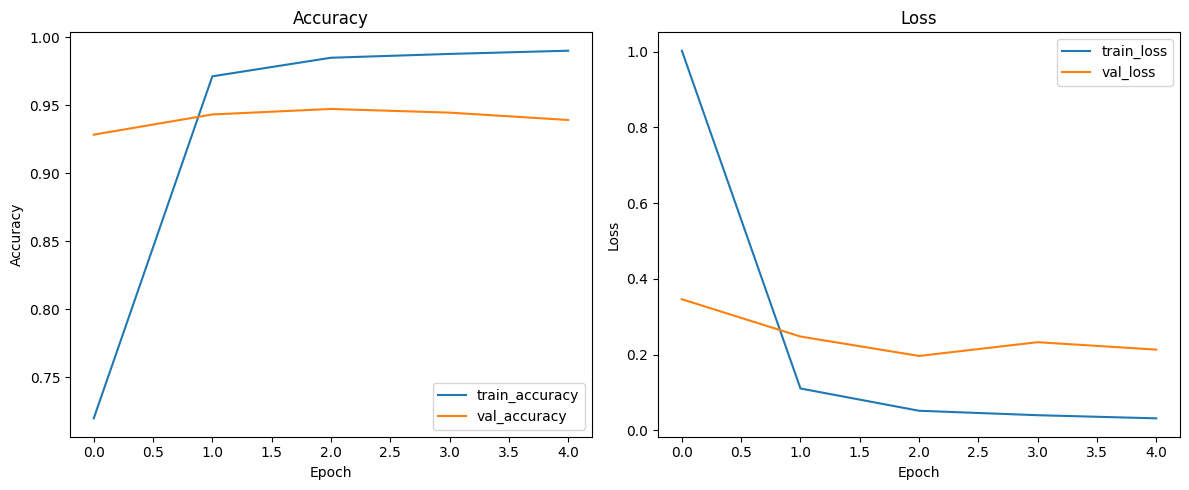

In [16]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
loss, acc = model.evaluate(x_val_bow, y_val)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9473 - loss: 0.1964


Приводим последовательности к одинаковой длине (обрезка) для подачи в модель

In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

x_train_emb = pad_sequences(x_train_seq, maxlen=WIN_SIZE)
x_val_emb   = pad_sequences(x_val_seq, maxlen=WIN_SIZE)

In [19]:
from tensorflow.keras.layers import Embedding, GlobalMaxPooling1D
model_emb = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=WIN_SIZE),

    GlobalMaxPooling1D(),  # сжимает текст в один вектор

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(CLASS_COUNT, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [20]:
model_emb.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history_emb = model_emb.fit(
    x_train_emb, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val_emb, y_val)
)

Epoch 1/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.2177 - loss: 2.5715 - val_accuracy: 0.3966 - val_loss: 2.1341
Epoch 2/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6757 - loss: 1.1545 - val_accuracy: 0.7000 - val_loss: 1.0604
Epoch 3/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8550 - loss: 0.5179 - val_accuracy: 0.7730 - val_loss: 0.7721
Epoch 4/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9199 - loss: 0.2959 - val_accuracy: 0.8155 - val_loss: 0.6646
Epoch 5/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9520 - loss: 0.1827 - val_accuracy: 0.8264 - val_loss: 0.6105
Epoch 6/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9711 - loss: 0.1180 - val_accuracy: 0.8453 - val_loss: 0.5706
Epoch 7/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9815 - loss: 0.0816 - val_accuracy: 0.8459 - val_loss: 0.5599
Epoch 8/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9871 - loss: 0.0596 - val_accuracy: 0

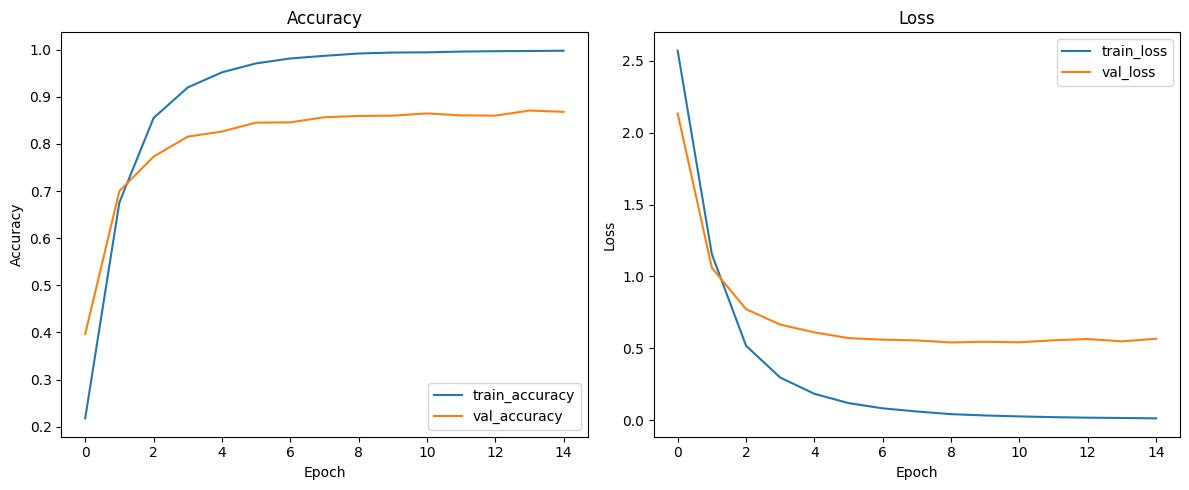

In [22]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_emb.history['accuracy'], label='train_accuracy')
plt.plot(history_emb.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_emb.history['loss'], label='train_loss')
plt.plot(history_emb.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()